### Predicting Monthly Electricity Consumption

## Project Overview

This project explores energy consumption patterns across hundreds of properties in Ontario.
The dataset consists of CSV files derived from the ENERGY STAR Portfolio Manager system.

Each CSV describes a different part of the data ecosystem:
1.	Property characteristics
2.	Meters installed at each property
3.	Monthly energy consumption readings
4.	How floor area is allocated to different use types

Each row in the meter entries dataset represents one monthly meter reading for a specific property.

Your main objective is to build a machine learning model that predicts monthly electricity consumption (usage) for buildings, using only readings from Electric – Grid meters (measured in kWh). 

The prediction target comes from the meter entries data, and you will need to extract the correct column and filter the dataset appropriately. You can use the attributes in these different files to help you in training your model.



### General Guidelines for the Project
Your work should demonstrate a complete data analytics workflow and communicate the results clearly.

Below are general expectations for the final report and code.
You may structure your project freely as long as these key components are included.


### 1. Data Cleaning
Prepare the dataset for meaningful analysis.
1.	Identify and handle missing values
(note: some fields use placeholders such as “Not Available”).
2.	Review and remove duplicates, inconsistencies, or invalid records.
3.	Ensure all columns use appropriate data types.
4.	Standardize categorical values where needed.
5.	Document any assumptions or decisions you make.
6.	In your report, clearly describe the major cleaning steps you performed and any issues you discovered.


### 2. Exploratory Data Analysis (EDA)
Develop a solid understanding of the dataset.
-	Compute summary statistics for relevant features.
-	Explore distributions and major patterns.
-	Examine how different attributes relate to the target variable.
-	Identify correlations, trends, or unusual observations.
-	In your report, present the most meaningful findings, not every calculation.


### 3. Visualization
Use visual tools to support and communicate insights.
-	Include plots such as histograms, bar charts, boxplots, or correlation heatmaps.
-	Label axes, titles, and legends clearly.
-	Include visualizations that add value to your analysis.
-	In your report, include figures that convey important insights and explain what they show.


### 4. Feature Engineering
Prepare the dataset for modeling.
-	Create new features where appropriate.
-	Encode categorical variables.
-	Normalize or scale numeric features if needed.
-	In your report, justify why certain features or transformations were used. Explain the reasoning behind selected features and transformations.


### 5. Model Building
Develop prediction models using the cleaned dataset.
-	Build at least two different models (e.g., different algorithms or pipelines).
-	Use an appropriate train–test split.
-	Apply preprocessing such as scaling or encoding when required.
-	Tune hyperparameters where helpful.
-	In your report, describe each model at a high level and the motivation for using it.


### 6. Model Evaluation
Assess model performance thoroughly.
-   Use appropriate metrics for your task.
-	Compare model performance and discuss strengths and weaknesses.
-	Visualize errors or residuals where relevant.
-	Consider issues such as outliers or skewed distributions. You may go back and improve your work in previous steps.
-	IMPORTANT: In your report, interpret what the evaluation results mean in context.


### 7. Insights, Interpretation, and Reporting
Synthesize your findings into a coherent narrative.
-	Summarize key insights found during EDA.
-	Discuss which factors appear to influence energy consumption.
-	Explain why certain models performed better than others.
-	Acknowledge limitations, assumptions, or data quality issues.
-	Suggest practical real-world implications or possible next steps.
-	Write your report clearly, logically, and professionally.


### 8. Code Quality and Reproducibility
Ensure your code is professional and easy to follow.
-	Use a Jupyter notebook to write and run your code.
-	Comment your code and use markdown cells where appropriate to explain key steps. 
-	Structure the notebook logically with clear section headings.
-	Make sure your code can be run by someone else without modification.
-	Avoid unnecessary duplication or unused code.
-	If your code needs anything special to run by someone else, briefly describe it in your report.


# Appendix:
## Data Dictionary



## Properties.csv

| Column Name                       | Description                              |
| --------------------------------- | ---------------------------------------- |
| **Property Name**                 | Name of the property or facility         |
| **Portfolio Manager ID**          | Unique property identifier               |
| **Street Address**                | Street address of the property           |
| **City/Municipality**             | City or municipality                     |
| **Postal Code**                   | Canadian postal code                     |
| **Property Type - Self-Selected** | Main type of property                    |
| **Gross Floor Area**              | Total property area (sq ft)              |
| **Occupancy (%)**                 | Percent of the building that is occupied |


## Meters.csv

| Column Name                        | Description                          |
| ---------------------------------- | ------------------------------------ |
| **Property Name**                  | Property this meter belongs to       |
| **Portfolio Manager ID**           | Property identifier                  |
| **Portfolio Manager Meter ID**     | Unique meter identifier              |
| **Meter Name**                     | Descriptive meter name               |
| **Meter Type**                     | Type of energy                       |
| **Units**                          | Unit for readings                    |
| **First Day of First Meter Entry** | Earliest reading date for this meter |
| **Last Day of Last Meter Entry**   | Latest reading date for this meter   |


## Meter Entries.csv

| Column Name                    | Description                         |
| ------------------------------ | ----------------------------------- |
| **Property Name**              | Property the reading belongs to     |
| **Portfolio Manager ID**       | Property identifier                 |
| **Portfolio Manager Meter ID** | Meter identifier                    |
| **Meter Name**                 | Name of the meter                   |
| **Meter Type**                 | Energy type                         |
| **Meter Consumption ID**       | Unique identifier for this reading  |
| **Start Date**                 | Start of usage period               |
| **End Date**                   | End of usage period                 |
| **Usage/Quantity**             | Amount of energy used in the period |
| **Usage Units**                | Unit of consumption                 |
| **Cost ($)**                   | Cost of the energy used             |


## Uses.csv
| Column Name                                 | Description                                          |
| ------------------------------------------- | ---------------------------------------------------- |
| **Property Name**                           | Property name                                        |
| **Portfolio Manager ID**                    | Property identifier                                  |
| **Property Use Name**                       | Name of the specific use area                        |
| **Use Type**                                | Category of space (Office, Gymnasium, Library, etc.) |
| **Gross Floor Area for Use**                | Floor area of this specific use type                 |
| **Gross Floor Area Units**                  | Units for floor area                                 |
| **Gross Floor Area Temporary Value? (Y/N)** | Indicates if the floor area value is temporary       |


## 0. Loading libraries and datasets

In [203]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [204]:
# Load dataset
meter_entries_df = pd.read_csv('datasets/meter_entries.csv')
meter_df = pd.read_csv('datasets/meters.csv')
properties_df = pd.read_csv('datasets/properties.csv')
uses_df = pd.read_csv('datasets/uses.csv')

## 1. Data Cleaning

In [205]:
# Number of rows and columns in each dataset
print("Meter Entries DataFrame shape:", meter_entries_df.shape)
print("Meter DataFrame shape:", meter_df.shape)
print("Properties DataFrame shape:", properties_df.shape)
print("Uses DataFrame shape:", uses_df.shape)


Meter Entries DataFrame shape: (26222, 11)
Meter DataFrame shape: (2585, 8)
Properties DataFrame shape: (1760, 8)
Uses DataFrame shape: (1760, 7)


In [206]:
# 1.1 Understand the datasets
print("Meter Entries DataFrame head:")
display(meter_entries_df.head())
print("Meter DataFrame head:")
display(meter_df.head())
print("Properties DataFrame head:")
display(properties_df.head())
print("Uses DataFrame head:")
display(uses_df.head())

Meter Entries DataFrame head:


,Property Name,Portfolio Manager ID,Portfolio Manager Meter ID,Meter Name,Meter Type,Meter Consumption ID,Start Date,End Date,Usage/Quantity,Usage Units,Cost ($)
0,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527469,2022-01-01 00:00:00,2022-02-01 00:00:00,42876.27,kWh (thousand Watt-hours),5775.7
1,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527470,2022-02-01 00:00:00,2022-03-01 00:00:00,39721.72,kWh (thousand Watt-hours),5377.67
2,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527471,2022-03-01 00:00:00,2022-04-01 00:00:00,41278.04,kWh (thousand Watt-hours),5611
3,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527472,2022-04-01 00:00:00,2022-05-01 00:00:00,37111.95,kWh (thousand Watt-hours),4989.06
4,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527473,2022-05-01 00:00:00,2022-06-01 00:00:00,41778.27,kWh (thousand Watt-hours),5984.66


Meter DataFrame head:


,Property Name,Portfolio Manager ID,Portfolio Manager Meter ID,Meter Name,Meter Type,Units,First Day of First Meter Entry,Last Day of Last Meter Entry
0,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,kWh (thousand Watt-hours),2010-01-01 00:00:00,2024-09-01 00:00:00
1,#13 Police Division,35000258,189947942,AUTO_#13 Police Division-Natural Gas,Natural Gas,cm (cubic meters),2010-01-01 00:00:00,2024-09-01 00:00:00
2,#22 Police Division,35000260,189947959,AUTO_#22 Police Division-Electric,Electric - Grid,kWh (thousand Watt-hours),2010-01-01 00:00:00,2024-05-01 00:00:00
3,#22 Police Division,35000260,189947960,AUTO_#22 Police Division-Natural Gas,Natural Gas,cm (cubic meters),2010-01-01 00:00:00,2024-05-01 00:00:00
4,#23 Police Division,35000261,189947990,AUTO_#23 Police Division-Electric,Electric - Grid,kWh (thousand Watt-hours),2010-01-01 00:00:00,2024-01-01 00:00:00


Properties DataFrame head:


,Property Name,Portfolio Manager ID,Street Address,City/Municipality,Postal Code,Property Type - Self-Selected,Gross Floor Area,Occupancy (%)
0,#11 Police Division - OLD,34999087,209 MAVETY ST,Toronto,M6P 2M1,Office,21119,100
1,#14 Police Division - OLD,34999088,150 HARRISON ST,Toronto,M6J 2A4,Office,24197,100
2,175 Memorial Park Ave,34999089,175 MEMORIAL PARK AVE,Toronto,M4J 2K5,Office,6394,100
3,18 Dyas Rd.,34999090,18 DYAS RD,North York,M3B 1V5,Office,73927,100
4,2 Civic Centre Court,34999091,2 CIVIC CENTRE CRT,Etobicoke,M9C 5A3,Office,46145,100


Uses DataFrame head:


,Property Name,Portfolio Manager ID,Property Use Name,Use Type,Gross Floor Area for Use,Gross Floor Area Units,Gross Floor Area Temporary Value? (Y/N)
0,#11 Police Division - OLD,34999087,Building Use,Office,21119.0,Sq. Ft.,No
1,#14 Police Division - OLD,34999088,Building Use,Office,24197.0,Sq. Ft.,No
2,175 Memorial Park Ave,34999089,Building Use,Office,6394.0,Sq. Ft.,No
3,18 Dyas Rd.,34999090,Building Use,Office,73927.0,Sq. Ft.,No
4,2 Civic Centre Court,34999091,Building Use,Office,46145.0,Sq. Ft.,No


In [207]:
print("\nMeter Entries DataFrame info:")
print(meter_entries_df.info())
print("------------------------------")
print("\nMeter DataFrame info:")
print(meter_df.info())
print("------------------------------")

print("\nProperties DataFrame info:")
print(properties_df.info())
print("------------------------------")

print("\nUses DataFrame info:")
print(uses_df.info())


Meter Entries DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26222 entries, 0 to 26221
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Property Name               26222 non-null  object 
 1   Portfolio Manager ID        26222 non-null  int64  
 2   Portfolio Manager Meter ID  26222 non-null  int64  
 3   Meter Name                  26222 non-null  object 
 4   Meter Type                  26222 non-null  object 
 5   Meter Consumption ID        26222 non-null  int64  
 6   Start Date                  26222 non-null  object 
 7   End Date                    26222 non-null  object 
 8   Usage/Quantity              26222 non-null  float64
 9   Usage Units                 26222 non-null  object 
 10  Cost ($)                    26222 non-null  object 
dtypes: float64(1), int64(3), object(7)
memory usage: 2.2+ MB
None
------------------------------

Meter DataFrame info

OK, here we can see that this datasets have some work needed to be done in terms of data cleaning and data types.
1. **dataset Meter Entries:**
- the columns 'Start Date' and 'End Date' are currently in object format; we need to convert them to datetime format for proper analysis.
- the column 'Cost ($)' should be numeric, but it may contain non-numeric values that need to be handled.

2. **dataset Meter:**
- the columns 'First Day of First Meter Entry' and 'Last Day of Last Meter Entry' are in object format; we need to convert them to datetime format.

3. **dataset Uses:**
- the column 'Gross Floor Area Temporary Value? (Y/N)' should be boolean, but it is currently in object format; we need to convert it to boolean type for accurate analysis.

In [208]:
# column data types
meter_entries_df[['Start Date', 'End Date']] = meter_entries_df[['Start Date', 'End Date']].apply(pd.to_datetime, errors='coerce')
meter_entries_df['Cost ($)'] = pd.to_numeric(meter_entries_df['Cost ($)'], errors='coerce')
meter_df[['First Day of First Meter Entry', 'Last Day of Last Meter Entry']] = meter_df[['First Day of First Meter Entry', 'Last Day of Last Meter Entry']].apply(pd.to_datetime, errors='coerce')
uses_df['Gross Floor Area Temporary Value? (Y/N)'] = uses_df['Gross Floor Area Temporary Value? (Y/N)'].map({'Yes': True, 'No': False})


In [209]:
# Analysis of data of Meter Entries unique values by columns
for column in meter_entries_df.columns:
    unique_values = meter_entries_df[column].nunique()
    print(f"Column '{column}' has {unique_values} unique values.")

Column 'Property Name' has 1672 unique values.
Column 'Portfolio Manager ID' has 1672 unique values.
Column 'Portfolio Manager Meter ID' has 2432 unique values.
Column 'Meter Name' has 2432 unique values.
Column 'Meter Type' has 5 unique values.
Column 'Meter Consumption ID' has 26222 unique values.
Column 'Start Date' has 25 unique values.
Column 'End Date' has 41 unique values.
Column 'Usage/Quantity' has 23951 unique values.
Column 'Usage Units' has 5 unique values.
Column 'Cost ($)' has 23413 unique values.


In [210]:
# Analysis of data Meter unique values by columns
for column in meter_df.columns:
    unique_values = meter_df[column].nunique()
    print(f"Column '{column}' has {unique_values} unique values.")

Column 'Property Name' has 1743 unique values.
Column 'Portfolio Manager ID' has 1743 unique values.
Column 'Portfolio Manager Meter ID' has 2585 unique values.
Column 'Meter Name' has 2585 unique values.
Column 'Meter Type' has 8 unique values.
Column 'Units' has 6 unique values.
Column 'First Day of First Meter Entry' has 377 unique values.
Column 'Last Day of Last Meter Entry' has 73 unique values.


In [211]:
# Analysis of data Uses unique values by columns
for column in uses_df.columns:
    unique_values = uses_df[column].nunique()
    print(f"Column '{column}' has {unique_values} unique values.")

Column 'Property Name' has 1760 unique values.
Column 'Portfolio Manager ID' has 1760 unique values.
Column 'Property Use Name' has 5 unique values.
Column 'Use Type' has 17 unique values.
Column 'Gross Floor Area for Use' has 930 unique values.
Column 'Gross Floor Area Units' has 2 unique values.
Column 'Gross Floor Area Temporary Value? (Y/N)' has 1 unique values.


In [212]:
# FUll DATA SET. MERGE ALL DATAFRAMES
# Keep the X columns from each dataframe to avoid duplication
full_df = meter_entries_df.merge(meter_df, on=['Portfolio Manager ID', 'Property Name', 'Meter Type'], how='inner') \
                          .merge(properties_df,on=['Portfolio Manager ID', 'Property Name'], how='inner') \
                          .merge(uses_df, on=['Portfolio Manager ID', 'Property Name'], how='inner')
full_df.drop(columns=['Portfolio Manager Meter ID_x', 'Portfolio Manager Meter ID_y'], inplace=True)

In [213]:
full_df.drop_duplicates(inplace=True, ignore_index=True)

In [214]:
full_df.head(15)

,Property Name,Portfolio Manager ID,Meter Name_x,Meter Type,Meter Consumption ID,Start Date,End Date,Usage/Quantity,Usage Units,Cost ($),...,City/Municipality,Postal Code,Property Type - Self-Selected,Gross Floor Area,Occupancy (%),Property Use Name,Use Type,Gross Floor Area for Use,Gross Floor Area Units,Gross Floor Area Temporary Value? (Y/N)
0,#13 Police Division,35000258,AUTO_#13 Police Division-Electric,Electric - Grid,8451527469,2022-01-01,2022-02-01,42876.27,kWh (thousand Watt-hours),5775.70,...,Toronto,M6C 3Z4,Police Station,20344,100,Building Use,Police Station,20344.0,Sq. Ft.,False
1,#13 Police Division,35000258,AUTO_#13 Police Division-Electric,Electric - Grid,8451527470,2022-02-01,2022-03-01,39721.72,kWh (thousand Watt-hours),5377.67,...,Toronto,M6C 3Z4,Police Station,20344,100,Building Use,Police Station,20344.0,Sq. Ft.,False
2,#13 Police Division,35000258,AUTO_#13 Police Division-Electric,Electric - Grid,8451527471,2022-03-01,2022-04-01,41278.04,kWh (thousand Watt-hours),5611.00,...,Toronto,M6C 3Z4,Police Station,20344,100,Building Use,Police Station,20344.0,Sq. Ft.,False
3,#13 Police Division,35000258,AUTO_#13 Police Division-Electric,Electric - Grid,8451527472,2022-04-01,2022-05-01,37111.95,kWh (thousand Watt-hours),4989.06,...,Toronto,M6C 3Z4,Police Station,20344,100,Building Use,Police Station,20344.0,Sq. Ft.,False
4,#13 Police Division,35000258,AUTO_#13 Police Division-Electric,Electric - Grid,8451527473,2022-05-01,2022-06-01,41778.27,kWh (thousand Watt-hours),5984.66,...,Toronto,M6C 3Z4,Police Station,20344,100,Building Use,Police Station,20344.0,Sq. Ft.,False
5,#13 Police Division,35000258,AUTO_#13 Police Division-Electric,Electric - Grid,8451527474,2022-06-01,2022-07-01,43191.93,kWh (thousand Watt-hours),7459.65,...,Toronto,M6C 3Z4,Police Station,20344,100,Building Use,Police Station,20344.0,Sq. Ft.,False
6,#13 Police Division,35000258,AUTO_#13 Police Division-Electric,Electric - Grid,8451527475,2022-07-01,2022-08-01,51529.45,kWh (thousand Watt-hours),10040.08,...,Toronto,M6C 3Z4,Police Station,20344,100,Building Use,Police Station,20344.0,Sq. Ft.,False
7,#13 Police Division,35000258,AUTO_#13 Police Division-Electric,Electric - Grid,8451527476,2022-08-01,2022-09-01,52583.64,kWh (thousand Watt-hours),9502.73,...,Toronto,M6C 3Z4,Police Station,20344,100,Building Use,Police Station,20344.0,Sq. Ft.,False
8,#13 Police Division,35000258,AUTO_#13 Police Division-Electric,Electric - Grid,8451527477,2022-09-01,2022-10-01,34396.96,kWh (thousand Watt-hours),5444.02,...,Toronto,M6C 3Z4,Police Station,20344,100,Building Use,Police Station,20344.0,Sq. Ft.,False
9,#13 Police Division,35000258,AUTO_#13 Police Division-Electric,Electric - Grid,8451527478,2022-10-01,2022-11-01,30086.82,kWh (thousand Watt-hours),2844.14,...,Toronto,M6C 3Z4,Police Station,20344,100,Building Use,Police Station,20344.0,Sq. Ft.,False


In [215]:
full_df.columns.tolist()

['Property Name',
 'Portfolio Manager ID',
 'Meter Name_x',
 'Meter Type',
 'Meter Consumption ID',
 'Start Date',
 'End Date',
 'Usage/Quantity',
 'Usage Units',
 'Cost ($)',
 'Meter Name_y',
 'Units',
 'First Day of First Meter Entry',
 'Last Day of Last Meter Entry',
 'Street Address',
 'City/Municipality',
 'Postal Code',
 'Property Type - Self-Selected',
 'Gross Floor Area',
 'Occupancy (%)',
 'Property Use Name',
 'Use Type',
 'Gross Floor Area for Use',
 'Gross Floor Area Units',
 'Gross Floor Area Temporary Value? (Y/N)']

In [216]:
import pandas as pd

unique_values = {}

for col in full_df.columns:
    # Convertimos todo a string temporalmente para poder inspeccionar
    vals = full_df[col].astype(str).unique()
    unique_values[col] = vals




In [217]:
full_df["moth"] = full_df["Start Date"].dt.month



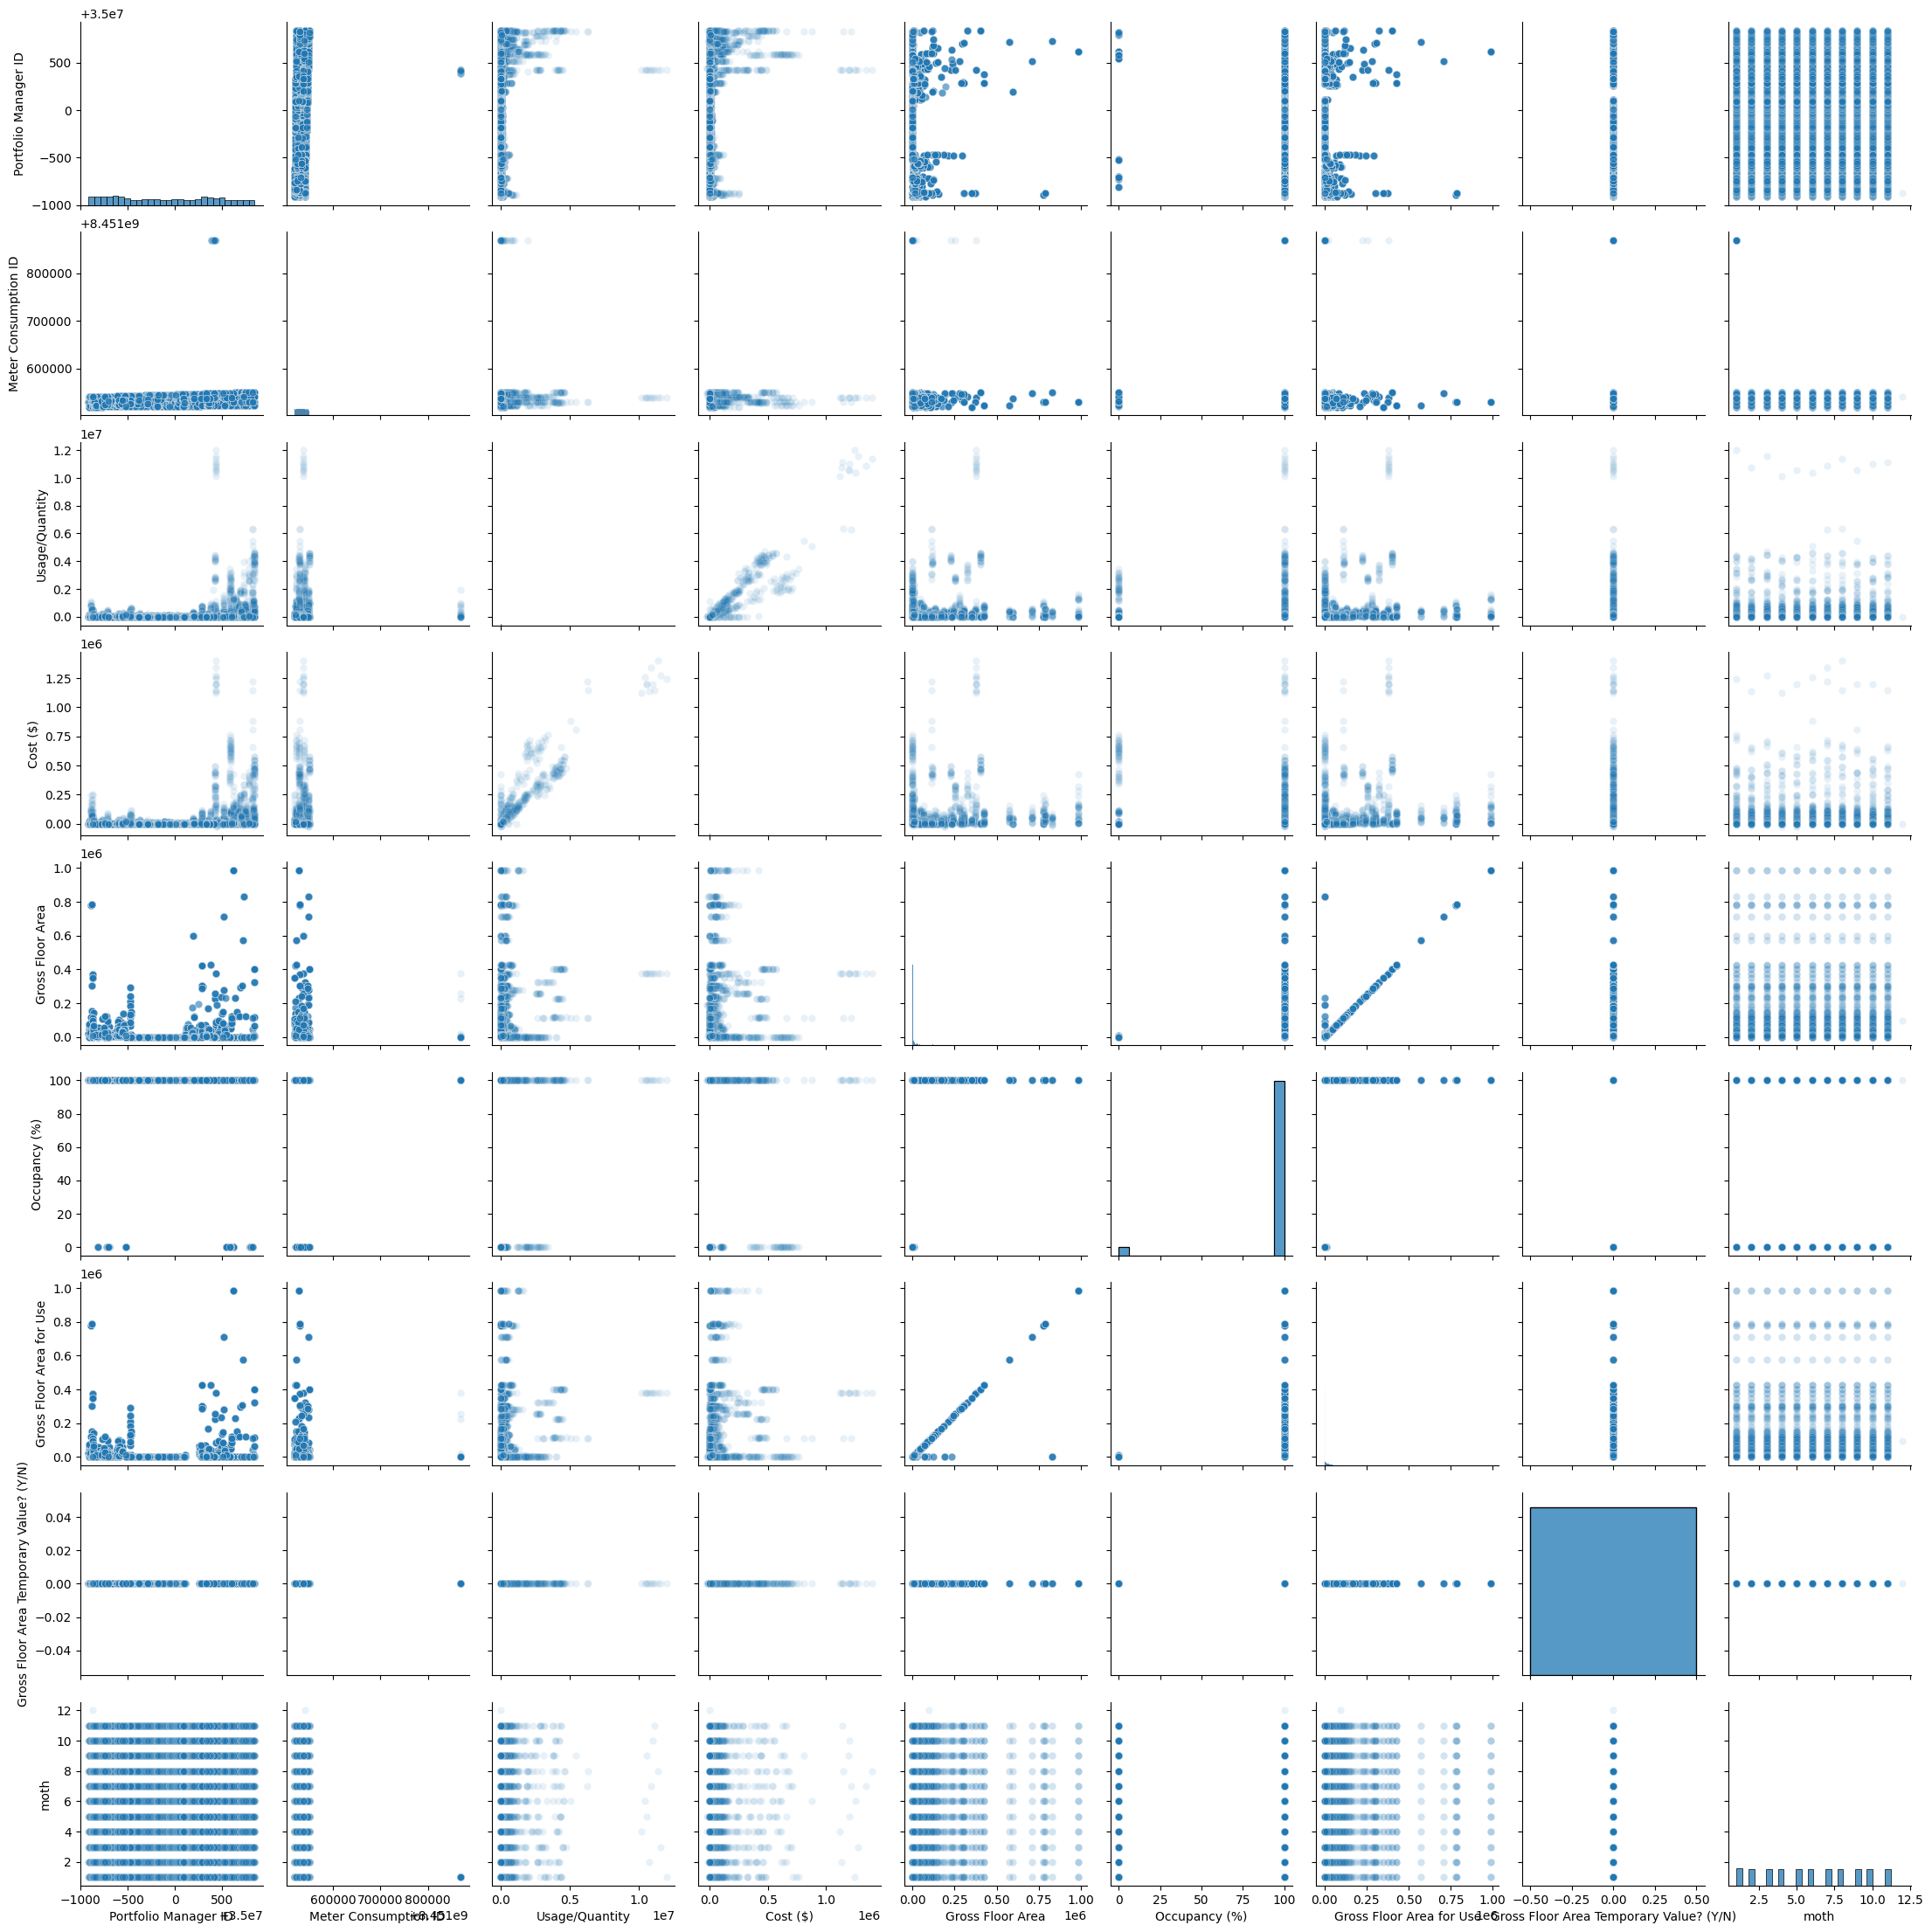

In [218]:
attributes = full_df.columns.tolist()
sns.pairplot(full_df[attributes], plot_kws={'alpha': 0.1})